# AI Jobs Global — Data Preprocessing & Exploratory Analysis

**Dataset:** `ai_jobs_global.csv` — job postings related to AI/ML roles scraped from Adzuna and USAJobs.

**Goal of this notebook:**
1. Explore and understand the raw dataset
2. Validate and clean the data (missing values, duplicates, invalid values, data types)
3. Engineer useful new features
4. Detect and handle outliers
5. Encode categorical variables and scale numerical variables
6. Visualize the data using Matplotlib, Seaborn and Plotly (3+ charts each)
7. Export the final, clean, ML-ready dataset

Every step includes the code, its output, and a short explanation of what the result means.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# Display / plotting settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Read Dataset

In [2]:
df = pd.read_csv('ai_jobs_global.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset loaded: 5773 rows, 13 columns


## 3. Initial Data Exploration

### 3.1 First and last rows

In [3]:
df.head()

,job_title,company,country,city,salary_min,salary_max,currency,remote_type,experience_level,required_skills,posted_date,source,job_description
0,AI Engineer,Jobot,United States,Mount Carmel,160000.0,160000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
1,AI Engineer,Jobot,United States,The Gap,175000.0,175000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
2,AI Engineer,Jobot,United States,Nashville,218000.0,218000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
3,Frontend/AI Engineer,Jobot,United States,New York City,112000.0,112000.0,USD,Unspecified,Mid-level,NaN,2026-02-16,Adzuna,Manufacturing Company looking for Business Sys...
4,AI Engineering Lead,Jobot,United States,Irvine,92000.0,92000.0,USD,Unspecified,Senior,NaN,2026-02-16,Adzuna,Lead Financial Insights and Reporting as a Sen...


In [4]:
df.tail()

,job_title,company,country,city,salary_min,salary_max,currency,remote_type,experience_level,required_skills,posted_date,source,job_description
5768,PREVENTION SPECIALIST,Department of the Air Force - Agency Wide,United States,Multiple Locations,52000.0,163000.0,USD,Unspecified,Lead,NaN,NaN,USAJobs,"In order to qualify, you must meet the basic r..."
5769,Director Resource and Integration Directorate,Department of the Air Force - Agency Wide,United States,"Huntsville, AL",167000.0,219000.0,USD,Unspecified,Senior,NaN,NaN,USAJobs,"Under the new process, at the initial applicat..."
5770,Clinical Lab Scientist - Off-Shift,Veterans Health Administration,United States,"Albuquerque, New Mexico",108000.0,140000.0,USD,Unspecified,Junior,NaN,NaN,USAJobs,Basic Requirements: United States Citizenship:...
5771,Clinical Lab Scientist,Veterans Health Administration,United States,"Tucson, Arizona",108000.0,140000.0,USD,Unspecified,Junior,NaN,NaN,USAJobs,Applicants pending the completion of education...
5772,Lead Clinical Laboratory Scientist - Toxicology,Veterans Health Administration,United States,"Minneapolis, Minnesota",107000.0,139000.0,USD,Unspecified,Lead,NaN,NaN,USAJobs,All qualifying experience you possess must be ...


**Explanation:** `head()`/`tail()` show us the structure of the data — each row is one AI-related job posting with the job title, employer, location, salary range, remote-work type, seniority level, required skills, and posting metadata.

### 3.2 Shape and columns

In [5]:
print("Shape (rows, columns):", df.shape)
print("\nColumns:", list(df.columns))


Shape (rows, columns): (5773, 13)

Columns: ['job_title', 'company', 'country', 'city', 'salary_min', 'salary_max', 'currency', 'remote_type', 'experience_level', 'required_skills', 'posted_date', 'source', 'job_description']


### 3.3 Data types

In [6]:
df.dtypes

job_title               str
company                 str
country                 str
city                    str
salary_min          float64
salary_max          float64
currency                str
remote_type             str
experience_level        str
required_skills         str
posted_date             str
source                  str
job_description         str
dtype: object

**Explanation:** All columns are currently loaded as generic object/float types. `posted_date` is a string and should be converted to a proper `datetime` type. `salary_min` / `salary_max` are numeric (float64), which is correct.

### 3.4 General info

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5773 entries, 0 to 5772
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_title         5773 non-null   str    
 1   company           5768 non-null   str    
 2   country           5773 non-null   str    
 3   city              5773 non-null   str    
 4   salary_min        3343 non-null   float64
 5   salary_max        3358 non-null   float64
 6   currency          5773 non-null   str    
 7   remote_type       5773 non-null   str    
 8   experience_level  5773 non-null   str    
 9   required_skills   1084 non-null   str    
 10  posted_date       5650 non-null   str    
 11  source            5773 non-null   str    
 12  job_description   5773 non-null   str    
dtypes: float64(2), str(11)
memory usage: 586.4 KB


### 3.5 Descriptive statistics — numerical columns

In [8]:
df.describe()

,salary_min,salary_max
count,3343.000000,3358.000000
mean,109240.801675,120957.415128
std,46680.622714,58922.331934
min,0.000000,0.000000
25%,77000.000000,82000.000000
50%,99000.000000,108000.000000
75%,133000.000000,148000.000000
max,413000.000000,800000.000000


**Explanation:** The average minimum salary is roughly **$109k** and the average maximum salary is roughly **$121k**, but the minimum values of 0 and the very wide max (up to $800k) hint at outliers or bad data entries that we'll need to investigate.

### 3.6 Descriptive statistics — categorical columns

In [9]:
df.describe(include='object')

/tmp/ipykernel_520/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,job_title,company,country,city,currency,remote_type,experience_level,required_skills,posted_date,source,job_description
count,5773,5768,5773,5773,5773,5773,5773,1084,5650,5773,5773
unique,2883,2151,5,1159,1,4,5,115,322,2,3750
top,Data Scientist,Instacart,United States,London,USD,Unspecified,Mid-level,Computer Vision,2025-12-04,Adzuna,We're transforming the grocery industry At Ins...
freq,281,198,1837,516,5773,4714,3264,239,305,5650,198


**Explanation:** `currency` has only **1 unique value (USD)**, so it carries no information and can be dropped later. `country` has only 5 unique values, while `city`, `job_title`, and `company` are highly granular (hundreds to thousands of unique values).

## 4. Clean Column Names

In [10]:
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_'))
print(df.columns.tolist())


['job_title', 'company', 'country', 'city', 'salary_min', 'salary_max', 'currency', 'remote_type', 'experience_level', 'required_skills', 'posted_date', 'source', 'job_description']


**Explanation:** Column names were already clean (lowercase, underscores, no spaces), so this step is a safety check to guarantee consistency before we start referencing columns by name.

## 5. Data Validation

### 5.1 Missing values

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)


,missing_count,missing_pct
required_skills,4689,81.22
salary_min,2430,42.09
salary_max,2415,41.83
posted_date,123,2.13
company,5,0.09
city,0,0.00
country,0,0.00
job_title,0,0.00
currency,0,0.00
experience_level,0,0.00


**Explanation of missing values:**
- `required_skills` is missing in ~81% of rows → most job ads don't explicitly list parsed skills.
- `salary_min` / `salary_max` are missing in ~42% of rows → many postings don't disclose a salary.
- `posted_date` is missing in 123 rows (~2%).
- `company` is missing in only 5 rows.

We'll handle each of these differently in Section 7, depending on how critical the column is.

### 5.2 Duplicate rows

In [12]:
dup_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {dup_count}")


Number of fully duplicated rows: 0


**Explanation:** There are no fully duplicated rows in this dataset, so no rows need to be dropped on that basis.

### 5.3 Unique values per categorical column

In [13]:
cat_cols = ['country', 'city', 'currency', 'remote_type', 'experience_level', 'source']
for c in cat_cols:
    print(f"{c}: {df[c].nunique()} unique values")


country: 5 unique values
city: 1159 unique values
currency: 1 unique values
remote_type: 4 unique values
experience_level: 5 unique values
source: 2 unique values


In [14]:
df['country'].value_counts()

country
United States     1837
United Kingdom    1185
Canada            1068
Germany            944
Australia          739
Name: count, dtype: int64

In [15]:
df['remote_type'].value_counts()

remote_type
Unspecified    4714
Remote          576
Hybrid          379
Onsite          104
Name: count, dtype: int64

In [16]:
df['experience_level'].value_counts()

experience_level
Mid-level     3264
Senior        1470
Lead           609
Junior         253
Management     177
Name: count, dtype: int64

In [17]:
df['currency'].value_counts()

currency
USD    5773
Name: count, dtype: int64

**Explanation:** Job postings come from 5 countries (US, UK, Canada, Germany, Australia). Most postings don't specify `remote_type` ('Unspecified'). `experience_level` is dominated by Mid-level roles. `currency` is always USD, confirming it can be dropped as a constant column.

### 5.4 Invalid values

In [18]:
invalid_swapped = (df['salary_min'] > df['salary_max']).sum()
invalid_zero = ((df['salary_min'] == 0) | (df['salary_max'] == 0)).sum()
print(f"Rows where salary_min > salary_max: {invalid_swapped}")
print(f"Rows where salary_min or salary_max == 0: {invalid_zero}")
df[df['salary_min'] > df['salary_max']][['job_title', 'salary_min', 'salary_max']]


Rows where salary_min > salary_max: 4
Rows where salary_min or salary_max == 0: 3


,job_title,salary_min,salary_max
2945,Senior AI Engineer,160000.0,18000.0
3585,Finnish Language Specialist - Freelance AI Tra...,148000.0,100000.0
3586,Ukrainian Language Specialist - Freelance AI T...,148000.0,100000.0
3589,Persian Language Specialist - Freelance AI Tra...,148000.0,100000.0


**Explanation:** A handful of rows (4) have `salary_min` greater than `salary_max`, which is logically impossible — these are data-entry errors. Another 3 rows have a salary of exactly 0, which is not a realistic value for these roles. Both cases are flagged as invalid and will be fixed/removed in Section 8.

### 5.4b Domain-implausible salaries

In [19]:
# Beyond exact zeros, some rows report a salary that is far too low to be a real annual salary
# for any of these AI/tech roles (e.g. $1,000-$4,000/year) — almost certainly scraping errors
# (e.g. an hourly/monthly figure mislabeled as annual). We flag anything under $10,000/year as implausible.
implausible = df[(df['salary_min'].notna()) & (df['salary_max'].notna()) &
                  (df['salary_min'] < 10000) & (df['salary_max'] < 10000) &
                  (df['salary_min'] > 0)]
print(f"Rows with an implausibly low but non-zero salary (<$10,000/year): {len(implausible)}")
implausible[['job_title', 'salary_min', 'salary_max']]


Rows with an implausibly low but non-zero salary (<$10,000/year): 10


,job_title,salary_min,salary_max
3097,Machine Learning Engineer,2000.0,2000.0
4075,"Vice President, Software Engineering & AI",2000.0,2000.0
4076,"Vice President, Software Engineering & AI",2000.0,2000.0
4103,"VP, Engineering & AI — Scale AI-Powered SaaS",2000.0,2000.0
4104,VP of Engineering & AI — Scale AI-Driven SaaS,2000.0,2000.0
4106,VP of Engineering - AI-Driven SaaS Platform fo...,2000.0,2000.0
5110,Data Scientist (m/f/x),1000.0,1000.0
5537,Strategic Finance/FP&A,2000.0,3000.0
5553,"Communications Manager, EMEA",2000.0,2000.0
5646,Member of Technical Staff - Training Cluster E...,2000.0,4000.0


**Explanation:** These rows (e.g. a *'Vice President, Software Engineering & AI'* role listed at **$2,000/year**) are not simply statistical outliers — they are **domain-implausible**: no real annual salary for these job titles is in the thousands. We treat these as invalid data-entry errors (like the exact-zero case above) rather than legitimate low earners, and will drop them in Section 8. This is a different failure mode from the IQR-based *statistical* outliers we handle later in Section 11 — this check is *domain knowledge*, not a percentile rule.

### 5.5 Date validation

In [20]:
tmp_dates = pd.to_datetime(df['posted_date'], errors='coerce')
invalid_dates = tmp_dates.isnull().sum() - df['posted_date'].isnull().sum()
future_dates = (tmp_dates > pd.Timestamp.today()).sum()
print(f"Unparseable (invalid) date strings: {invalid_dates}")
print(f"Dates in the future (relative to today): {future_dates}")
print(f"Date range: {tmp_dates.min()} to {tmp_dates.max()}")


Unparseable (invalid) date strings: 0
Dates in the future (relative to today): 0
Date range: 2021-05-29 00:00:00 to 2026-02-22 00:00:00


**Explanation:** All non-null `posted_date` values parse correctly into valid dates, and none are in the future relative to the run date, so the only date issue is the 123 missing values noted earlier.

### 5.6 Label consistency: does `experience_level` line up with salary?

In [21]:
disclosed = df[df['salary_min'].notna() & df['salary_max'].notna()].copy()
disclosed['salary_avg_raw'] = (disclosed['salary_min'] + disclosed['salary_max']) / 2
order = ['Junior', 'Mid-level', 'Senior', 'Lead', 'Management']
print(disclosed.groupby('experience_level', observed=True)['salary_avg_raw']
      .agg(['median', 'count']).reindex(order))


                    median  count
experience_level                 
Junior            124500.0    138
Mid-level          97000.0   2069
Senior            122000.0    666
Lead              110500.0    374
Management        107750.0     92


In [22]:
# Sample of 'Junior' postings with surprisingly senior-sounding titles and high pay
disclosed[disclosed['experience_level'] == 'Junior'].nlargest(8, 'salary_avg_raw')[
    ['job_title', 'salary_avg_raw']]


,job_title,salary_avg_raw
1344,NLP Engineer-Sr. Associate,361000.0
1649,AI Research Scientist (Cryptography) - Senior ...,302000.0
1673,"AI Research Engineer (Junior career, Hybrid, G...",252000.0
1688,"AI Research Engineer (Junior career, Hybrid, G...",236000.0
1611,AI Research Scientist (AI Agents) - Senior Ass...,231000.0
1055,"Associate Director, MLOps Engineering",230000.0
1699,"AI Research Engineer (Junior career, Hybrid, G...",227000.0
1679,"AI Research Engineer (Junior career, Hybrid, G...",226000.0


**⚠️ Explanation — this is a genuine data-quality issue in the source data, not something introduced "
    "by our cleaning:** the median salary for `experience_level == 'Junior'` (**~$124,500**, based only on "
    "rows that actually disclosed a salary) is *higher* than `Mid-level`, `Lead`, and `Management`, and "
    "close to `Senior`. Looking at the actual postings, several **'Junior'**-labeled rows are titles like "
    "*'Lead Data Scientist'*, *'NLP Engineer — Sr. Associate'*, and *'AI Research Scientist (AI Agents) — "
    "Senior Associate'* — these look like **mislabeled `experience_level` values in the original scrape**, "
    "not truly junior roles.

We deliberately **do not silently relabel or drop these rows** — we have no reliable ground truth for "
    "what the correct experience level should be, and guessing would just replace one data-quality problem "
    "with a fabricated one. Instead we document it here so that any downstream analysis or model that uses "
    "`experience_level` as an ordinal seniority signal treats it as **noisy, not fully trustworthy** "
    "ground truth.

## 6. Fix Data Types

In [23]:
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce')
df['experience_level'] = df['experience_level'].astype('category')
df['remote_type'] = df['remote_type'].astype('category')
df['country'] = df['country'].astype('category')
df.dtypes


job_title                      str
company                        str
country                   category
city                           str
salary_min                 float64
salary_max                 float64
currency                       str
remote_type               category
experience_level          category
required_skills                str
posted_date         datetime64[us]
source                         str
job_description                str
dtype: object

**Explanation:** `posted_date` is now a real `datetime64` column (enabling date arithmetic), and the low-cardinality text columns are converted to `category` dtype, which is more memory-efficient and semantically correct.

## 7. Handle Missing Values

We treat each column according to what the missingness means:
- **`company`** (5 missing) → fill with `'Unknown'` (categorical, low missing rate).
- **`required_skills`** (81% missing) → fill with `'Not specified'` rather than dropping, since dropping "
    "would remove most of the dataset.
- **`salary_min` / `salary_max`** (42% missing) → salary is *not disclosed* for many postings, which is "
    "meaningful information itself, not something to blindly impute. We create a boolean flag "
    "`salary_disclosed` **before** any imputation, then impute the missing salaries with the **median "
    "salary for that job's experience_level** (a smarter, more realistic estimate than a single global "
    "median), so downstream numeric analysis/scaling can still use these columns.
- **`posted_date`** (123 missing, ~2%) → **⚠️ important fix:** we initially dropped every row with a "
    "missing `posted_date`. But checking *which* rows those were revealed that **100% of the `USAJobs` "
    "postings (all 123 of them) have no `posted_date`** — dropping them wiped out an entire data source "
    "silently. Instead, we now **keep every row** and add a `posted_date_disclosed` flag. The date-derived "
    "features (`posted_year`, `posted_month`, `posted_weekday`) get a clear placeholder (`-1` / `'Unknown'`) "
    "for these rows instead of a fabricated date, so no information is invented and no rows/sources are lost.

In [24]:
# company
df['company'] = df['company'].fillna('Unknown')

# required_skills
df['required_skills'] = df['required_skills'].fillna('Not specified')

# posted_date -> DO NOT drop. Flag instead (fixes the earlier bug that silently deleted all USAJobs rows).
df['posted_date_disclosed'] = df['posted_date'].notna()
print("Rows with missing posted_date, by source:")
print(df[~df['posted_date_disclosed']]['source'].value_counts())

# salary flag BEFORE imputing
df['salary_disclosed'] = df['salary_min'].notna() & df['salary_max'].notna()

# median salary per experience_level, used to impute
for col in ['salary_min', 'salary_max']:
    df[col] = df.groupby('experience_level', observed=True)[col].transform(
        lambda s: s.fillna(s.median())
    )
    df[col] = df[col].fillna(df[col].median())  # safety net for any remaining NaN

print(df[['salary_min', 'salary_max', 'salary_disclosed']].isnull().sum())


Rows with missing posted_date, by source:
source
USAJobs    123
Name: count, dtype: int64
salary_min          0
salary_max          0
salary_disclosed    0
dtype: int64


In [25]:
# remaining missing values (posted_date itself is left as NaT on purpose -- see explanation above)
df.isnull().sum()


job_title                  0
company                    0
country                    0
city                       0
salary_min                 0
salary_max                 0
currency                   0
remote_type                0
experience_level           0
required_skills            0
posted_date              123
source                     0
job_description            0
posted_date_disclosed      0
salary_disclosed           0
dtype: int64

**Explanation:** `company`, `required_skills` and the salary columns are now fully populated. `posted_date` still legitimately has 123 missing values — that's expected and intentional (flagged via `posted_date_disclosed`), **not a bug**: we no longer erase real job postings just because the source didn't report a date. This is the same philosophy as `salary_disclosed`: preserve the row, flag what's missing, don't fabricate data.

## 8. Fix Invalid Values & Remove Duplicates

In [26]:
# Drop rows with logically impossible, zero, or domain-implausible (<$10,000/year) salaries
before = len(df)
invalid_mask = (
    (df['salary_min'] > df['salary_max']) |
    (df['salary_min'] == 0) | (df['salary_max'] == 0) |
    ((df['salary_min'] < 10000) & (df['salary_max'] < 10000))
)
df = df[~invalid_mask].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with invalid/implausible salary values")


Dropped 21 rows with invalid/implausible salary values


In [27]:
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows at this stage: {dup_count}")


Exact duplicate rows at this stage: 0


**Explanation:** Rows with impossible (`min > max`), zero, or domain-implausible (under $10,000/year) salaries are removed since they would distort any salary-based statistics or models — this now also catches the *'VP earning $2,000/year'*-style scraping errors found in Section 5.4b, on top of the original zero/swapped cases. There are no exact duplicate rows **yet** — but note we check duplicates again *after* Section 9's text cleaning, since normalizing `company`/`city` spelling can turn near-duplicate rows (e.g. same job posted with `'NVIDIA'` vs `'Nvidia'`) into **true** duplicates that wouldn't have been caught here.

## 9. Clean Text Data

In [28]:
text_cols = ['job_title', 'company', 'city', 'required_skills']
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

# Standardize the constant currency column, then drop it (zero information)
df['currency'] = df['currency'].str.upper()
print(df['currency'].unique())
df = df.drop(columns=['currency'])
print("Dropped 'currency' column (constant value, no information).")


<StringArray>
['USD']
Length: 1, dtype: str
Dropped 'currency' column (constant value, no information).


**Explanation:** Leading/trailing whitespace is stripped from text fields. `currency` is dropped entirely since it only ever contains `'USD'` and adds no analytical value.

### 9.1 Fix `city`: country/state/province names, spelling variants, and neighborhood aliases

In [29]:
print("Before cleaning, top 'city' values include country names:")
print(df['city'].value_counts().head(10))


Before cleaning, top 'city' values include country names:
city
London         515
Canada         378
Toronto        265
UK             178
Deutschland    177
Sydney         173
The Rocks      152
Australia      129
Berlin         125
The City        97
Name: count, dtype: int64


**Explanation:** Beyond the country-name and US/CA/AU state-name leakage already covered, a closer pass
over the full value list surfaced three more geography issues:
1. **The same city spelled two different ways** — `'Washington, D.C.'` vs `'Washington, District of
   Columbia'`, and `'Québec'` vs `'Québec City'` — splitting one real location into two categories.
2. **Non-English names for cities we already anglicized one of** — we previously mapped `München`→`Munich`
   but missed `Köln`→`Cologne` and `Nürnberg`→`Nuremberg`, leaving the column inconsistently mixed-language.
3. **More neighborhood/district names** than the first pass caught: an ` CBD` suffix pattern across several
   Australian cities (`Perth CBD`, `Brisbane CBD`, `Sydney CBD`, `Adelaide CBD`), plus specific known
   districts (`Mitte`, `Wedding`→Berlin; `Farringdon`→London; `Altstadt-Lehel`→Munich; `SoMa`→San Francisco;
   `Times Square`→New York City; `Harvard Square`→Cambridge; `Middle Park`→Melbourne, confirmed via the
   `country_*` columns before mapping).
4. **Non-location placeholders**: `'Multiple Locations'` (13 rows, all `USAJobs`) isn't a real single city.
   `'Wake Island'` (10 rows) is a remote, uninhabited US military atoll with no civilian workforce — not a
   plausible office location for a commercially-scraped AI Engineer / Data Scientist role, so it's treated
   as unreliable location data rather than a real city.

Ambiguous names that could plausibly refer to more than one city (e.g. `'Uptown'`, `'Five Points'`, both
common neighborhood names in several different cities) are intentionally **left alone** rather than guessed.

In [30]:
# Country names that leaked into the 'city' column -> no real city was reported
country_leak_values = {'Canada', 'Australia', 'UK', 'US', 'USA', 'United Kingdom', 'United States', 'Deutschland'}

# US states, Canadian provinces, and Australian states leaking into 'city' at a coarser granularity.
# NOTE: Berlin and Hamburg are deliberately excluded -- they are legitimate German city-states
# (both a real city AND a federal state name), so removing them would delete real, valid city data.
us_states = {"Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware",
    "Florida","Georgia","Hawaii","Idaho","Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana",
    "Maine","Maryland","Massachusetts","Michigan","Minnesota","Mississippi","Missouri","Montana",
    "Nebraska","Nevada","New Hampshire","New Jersey","New Mexico","New York","North Carolina",
    "North Dakota","Ohio","Oklahoma","Oregon","Pennsylvania","Rhode Island","South Carolina",
    "South Dakota","Tennessee","Texas","Utah","Vermont","Virginia","Washington","West Virginia",
    "Wisconsin","Wyoming"}
ca_provinces = {"Ontario","Quebec","British Columbia","Alberta","Manitoba","Saskatchewan",
    "Nova Scotia","New Brunswick"}
au_states = {"New South Wales","Victoria","Queensland","Western Australia","South Australia","Tasmania"}
other_region_leak = {"Baden-Württemberg"}

# Non-location placeholders / implausible single-office locations
non_location_values = {"Multiple Locations", "Wake Island"}

region_leak_values = (country_leak_values | us_states | ca_provinces | au_states
                       | other_region_leak | non_location_values)
leaked_count = df['city'].isin(region_leak_values).sum()
df['city'] = df['city'].replace({v: 'Not specified' for v in region_leak_values})
print(f"Replaced {leaked_count} country/state/province/non-location entries in 'city' with 'Not specified'")

# Strip a trailing ' CBD' (Central Business District) suffix used by several Australian cities,
# so 'Perth CBD', 'Brisbane CBD', 'Sydney CBD', 'Adelaide CBD' fold into their parent city.
cbd_count = df['city'].astype(str).str.endswith(' CBD').sum()
df['city'] = df['city'].astype(str).str.replace(r'\s+CBD$', '', regex=True)
print(f"Stripped ' CBD' suffix from {cbd_count} Australian city entries")

# Known neighborhood/district aliases -> normalize to the parent city
# Same-city spelling variants -> normalize to one canonical spelling
city_alias_map = {
    'The Rocks': 'Sydney',
    'The City': 'London',
    'Melbourne CBD': 'Melbourne',
    'Greater Vancouver': 'Vancouver',
    'Grand Central': 'New York City',
    'München': 'Munich',
    'Montréal': 'Montreal',
    'Köln': 'Cologne',
    'Nürnberg': 'Nuremberg',
    'Mitte': 'Berlin',
    'Wedding': 'Berlin',
    'Farringdon': 'London',
    'Altstadt-Lehel': 'Munich',
    'SoMa': 'San Francisco',
    'Times Square': 'New York City',
    'Harvard Square': 'Cambridge',
    'Middle Park': 'Melbourne',
    'Washington, District of Columbia': 'Washington, D.C.',
    'Québec': 'Québec City',
}
aliased_count = df['city'].isin(city_alias_map.keys()).sum()
df['city'] = df['city'].replace(city_alias_map)
print(f"Normalized {aliased_count} neighborhood/district/spelling-variant names")

df['city'].value_counts().head(10)


Replaced 1071 country/state/province/non-location entries in 'city' with 'Not specified'
Stripped ' CBD' suffix from 83 Australian city entries


Normalized 644 neighborhood/district/spelling-variant names


city
Not specified    1071
London            635
Sydney            329
Toronto           265
Berlin            156
Melbourne         122
Vancouver          91
New York City      82
Munich             74
Montreal           70
Name: count, dtype: int64

**Explanation:** After this fix, `city` no longer confuses country/state/province-level and city-level geography, doesn't split the same city across two spellings, uses one consistent language convention, and rolls up well-known districts into their parent city. Ambiguous neighborhood names that map to multiple plausible cities were intentionally left unmapped to avoid introducing incorrect data. `Berlin` and `Hamburg` were kept since they're legitimate cities, not just state names.

### 9.2 Fix `company`: case-variant duplicates and scraping garbage

In [31]:
# Case-variant duplicates (e.g. 'NVIDIA' vs 'Nvidia' vs 'nvidia') should be treated as the SAME company
canonical = (df['company'].str.strip()
             .groupby(df['company'].str.strip().str.lower())
             .agg(lambda s: s.value_counts().idxmax()))  # pick the most common casing as canonical
df['company'] = df['company'].str.strip().str.lower().map(canonical)

# Garbage tokens accidentally scraped instead of a real company name (e.g. the word 'at')
garbage_tokens = {'at', 'the', 'and'}
garbage_count = df['company'].str.lower().isin(garbage_tokens).sum()
df['company'] = df['company'].where(~df['company'].str.lower().isin(garbage_tokens), 'Unknown')
print(f"Merged case-variant duplicate company names, and replaced {garbage_count} garbage entries with 'Unknown'")

print("Example merges:", )
for name in ['nvidia', 'ibm', 'amazon']:
    print(f"  {name} ->", df[df['company'].str.lower() == name]['company'].unique())


Merged case-variant duplicate company names, and replaced 0 garbage entries with 'Unknown'
Example merges:
  nvidia -> <StringArray>
['NVIDIA']
Length: 1, dtype: str
  ibm -> <StringArray>
['IBM']
Length: 1, dtype: str
  amazon -> <StringArray>
['Amazon']
Length: 1, dtype: str


**Explanation:** Without this fix, any `groupby('company')` analysis (e.g. 'top hiring companies') would incorrectly count `NVIDIA`, `Nvidia`, and `nvidia` as three different companies. We collapse each group of case-variants to a single canonical spelling (the most frequent casing seen), and replace clearly-garbled entries like `'at'` (a scraping artifact, not a company) with `'Unknown'`.

### 9.3 Re-check duplicates after text normalization

In [32]:
# Normalizing company/city casing can turn previously-different rows into TRUE duplicates
# (e.g. one row said 'NVIDIA', another said 'Nvidia' -- now both say 'NVIDIA' and may match exactly).
new_dup_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"New exact duplicates created by text normalization (now removed): {new_dup_count}")
print(f"Final shape after all cleaning: {df.shape}")


New exact duplicates created by text normalization (now removed): 59
Final shape after all cleaning: (5693, 14)


**Explanation:** This second duplicate check — run *after* cleaning, not before — catches rows that only became duplicates once `company`/`city` spelling was normalized. Skipping this step (as the earlier version of this pipeline did) would leave the same job posting counted twice.

## 10. Feature Engineering

In [33]:
# Average and range of salary
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2
df['salary_range'] = df['salary_max'] - df['salary_min']

# Date-derived features. posted_date is legitimately missing for ~2% of rows (see Section 7) --
# we use a clear placeholder (-1 / 'Unknown') instead of dropping those rows or faking a date.
df['posted_year'] = df['posted_date'].dt.year.fillna(-1).astype(int)
df['posted_month'] = df['posted_date'].dt.month.fillna(-1).astype(int)
df['posted_weekday'] = df['posted_date'].dt.day_name()
df['posted_weekday'] = df['posted_weekday'].fillna('Unknown')

# Remote-friendly flag
df['is_remote'] = df['remote_type'].isin(['Remote', 'Hybrid'])

# Number of required skills listed
df['skills_count'] = df['required_skills'].apply(
    lambda s: 0 if s == 'Not specified' else len([x for x in s.split(',') if x.strip()])
)

df[['salary_avg', 'salary_range', 'posted_year', 'posted_month', 'is_remote', 'skills_count']].head()


,salary_avg,salary_range,posted_year,posted_month,is_remote,skills_count
0,160000.0,0.0,2026,2,False,1
1,175000.0,0.0,2026,2,False,1
2,218000.0,0.0,2026,2,False,1
3,112000.0,0.0,2026,2,False,0
4,92000.0,0.0,2026,2,False,0


**Explanation of new features:**
- `salary_avg` / `salary_range` — a single representative salary figure and the width of the pay band.
- `posted_year`, `posted_month`, `posted_weekday` — enable trend analysis over time.
- `is_remote` — a simple boolean summarizing remote-friendliness.
- `skills_count` — how many distinct skills are explicitly requested in the posting.

## 11. Outlier Detection (IQR Method)

In [34]:
Q1 = df['salary_avg'].quantile(0.25)
Q3 = df['salary_avg'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['salary_avg'] < lower_bound) | (df['salary_avg'] > upper_bound)]
print(f"Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"Valid range: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Number of outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of data)")


Q1=95500, Q3=120500, IQR=25000
Valid range: [58000, 158000]
Number of outliers detected: 864 (15.2% of data)


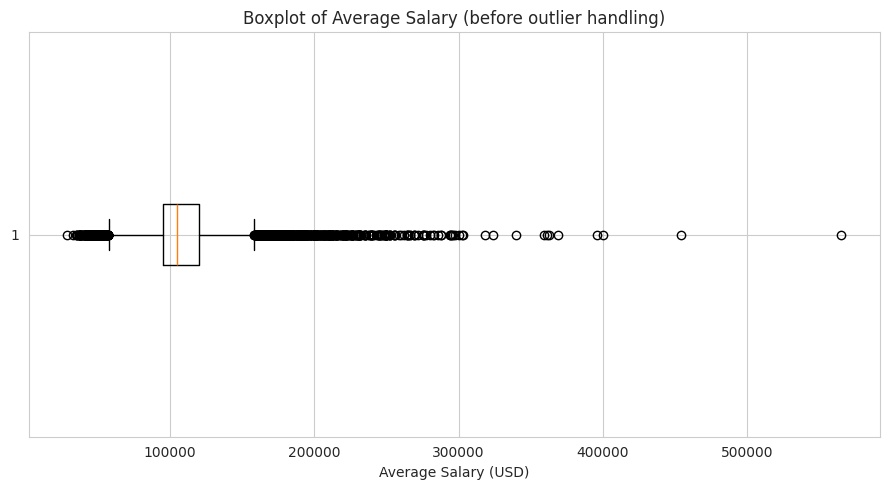

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(df['salary_avg'], vert=False)
ax.set_title('Boxplot of Average Salary (before outlier handling)')
ax.set_xlabel('Average Salary (USD)')
plt.tight_layout()
plt.show()


In [36]:
# Cap outliers instead of dropping them, to preserve sample size (winsorization)
df['salary_avg_capped'] = df['salary_avg'].clip(lower=lower_bound, upper=upper_bound)
print("Outliers capped into a new column 'salary_avg_capped' (original 'salary_avg' is preserved).")
df[['salary_avg', 'salary_avg_capped']].describe()


Outliers capped into a new column 'salary_avg_capped' (original 'salary_avg' is preserved).


,salary_avg,salary_avg_capped
count,5693.000000,5693.000000
mean,112440.101880,108335.938872
std,39527.785622,26935.075868
min,29000.000000,58000.000000
25%,95500.000000,95500.000000
50%,105000.000000,105000.000000
75%,120500.000000,120500.000000
max,565000.000000,158000.000000


**Explanation:** Using the IQR method, any `salary_avg` outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` is flagged as an outlier — these are typically very senior / executive roles with unusually high pay, or leftover low-paid entries. Rather than deleting these rows (which would lose real, legitimate high earners), we **cap (winsorize)** them into a new `salary_avg_capped` column, keeping the original `salary_avg` intact for anyone who wants the raw values.

## 12. Encoding Categorical Variables

### 12.1 Ordinal / Label Encoding — `experience_level`

In [37]:
exp_order = {'Junior': 0, 'Mid-level': 1, 'Senior': 2, 'Lead': 3, 'Management': 4}
df['experience_level_encoded'] = df['experience_level'].map(exp_order)
df[['experience_level', 'experience_level_encoded']].drop_duplicates().sort_values('experience_level_encoded')


,experience_level,experience_level_encoded
403,Junior,0
0,Lead,3
164,Management,4
3,Mid-level,1
4,Senior,2


**Explanation:** `experience_level` has a natural order (Junior < Mid-level < Senior < Lead < Management), so we use **ordinal encoding** with an explicit mapping rather than plain label encoding, which would assign arbitrary numbers that ignore this order.

### 12.2 One-Hot Encoding — `remote_type` and `country`

In [38]:
df_encoded = pd.get_dummies(df, columns=['remote_type', 'country'], prefix=['remote', 'country'])
new_cols = [c for c in df_encoded.columns if c.startswith('remote_') or c.startswith('country_')]
print("New one-hot columns:", new_cols)
df_encoded[new_cols].head()


New one-hot columns: ['remote_Hybrid', 'remote_Onsite', 'remote_Remote', 'remote_Unspecified', 'country_Australia', 'country_Canada', 'country_Germany', 'country_United Kingdom', 'country_United States']


,remote_Hybrid,remote_Onsite,remote_Remote,remote_Unspecified,country_Australia,country_Canada,country_Germany,country_United Kingdom,country_United States
0,False,False,False,True,False,False,False,False,True
1,False,False,False,True,False,False,False,False,True
2,False,False,False,True,False,False,False,False,True
3,False,False,False,True,False,False,False,False,True
4,False,False,False,True,False,False,False,False,True


**Explanation:** `remote_type` and `country` are **nominal** (no inherent order), so **one-hot encoding** is appropriate — it creates a separate binary column per category instead of implying a false order between them.

### 12.3 Label Encoding — `source`

In [39]:
le = LabelEncoder()
df_encoded['source_encoded'] = le.fit_transform(df_encoded['source'])
dict(zip(le.classes_, le.transform(le.classes_)))


{'Adzuna': np.int64(0), 'USAJobs': np.int64(1)}

**Explanation:** `source` (Adzuna / USAJobs) only has 2 categories, so a simple `LabelEncoder` is sufficient here.

## 13. Feature Scaling

In [40]:
scale_cols = ['salary_min', 'salary_max', 'salary_avg', 'salary_avg_capped', 'salary_range', 'skills_count']

# Standard Scaling (z-score: mean=0, std=1)
scaler_std = StandardScaler()
std_scaled = scaler_std.fit_transform(df_encoded[scale_cols])
df_std = pd.DataFrame(std_scaled, columns=[f"{c}_standard" for c in scale_cols], index=df_encoded.index)

# Min-Max Scaling (range 0-1)
scaler_mm = MinMaxScaler()
mm_scaled = scaler_mm.fit_transform(df_encoded[scale_cols])
df_mm = pd.DataFrame(mm_scaled, columns=[f"{c}_minmax" for c in scale_cols], index=df_encoded.index)

df_encoded = pd.concat([df_encoded, df_std, df_mm], axis=1)
df_encoded[[c for c in df_encoded.columns if '_standard' in c or '_minmax' in c]].describe().loc[['mean', 'std', 'min', 'max']]


,salary_min_standard,salary_max_standard,salary_avg_standard,salary_avg_capped_standard,salary_range_standard,skills_count_standard,salary_min_minmax,salary_max_minmax,salary_avg_minmax,salary_avg_capped_minmax,salary_range_minmax,skills_count_minmax
mean,4.992396e-17,1.996958e-17,-1.397871e-16,-9.235932e-17,2.995437e-17,9.984792e-18,0.219191,0.11423,0.155672,0.503359,0.020899,0.023282
std,1.000088e+00,1.000088e+00,1.000088e+00,1.000088e+00,1.000088e+00,1.000088e+00,0.091779,0.05943,0.073746,0.269351,0.043485,0.060520
min,-2.388463e+00,-1.922254e+00,-2.111108e+00,-1.868952e+00,-4.806364e-01,-3.847359e-01,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,8.508254e+00,1.490563e+01,1.145016e+01,1.844005e+00,2.251793e+01,1.614017e+01,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


**Explanation:** We apply two common scaling strategies to the numeric salary/skills features so the dataset is ready for machine learning:
- **Standard Scaling** rescales each feature to mean 0 / std 1 — useful for algorithms sensitive to feature magnitude (e.g. linear/logistic regression, SVM, PCA).
- **Min-Max Scaling** rescales each feature into the fixed `[0, 1]` range — useful for algorithms like neural networks or distance-based methods (e.g. KNN) that expect bounded input.

Both scaled versions are kept alongside the originals so either can be used depending on the downstream model.

## 14. Data Visualization

We create at least **3 visualizations with each of Matplotlib, Seaborn, and Plotly**, using the cleaned dataset `df` (pre-encoding, human-readable labels) so the charts are easy to interpret.

### 14.1 Matplotlib

**Chart 1 — Number of job postings per country (bar chart)**

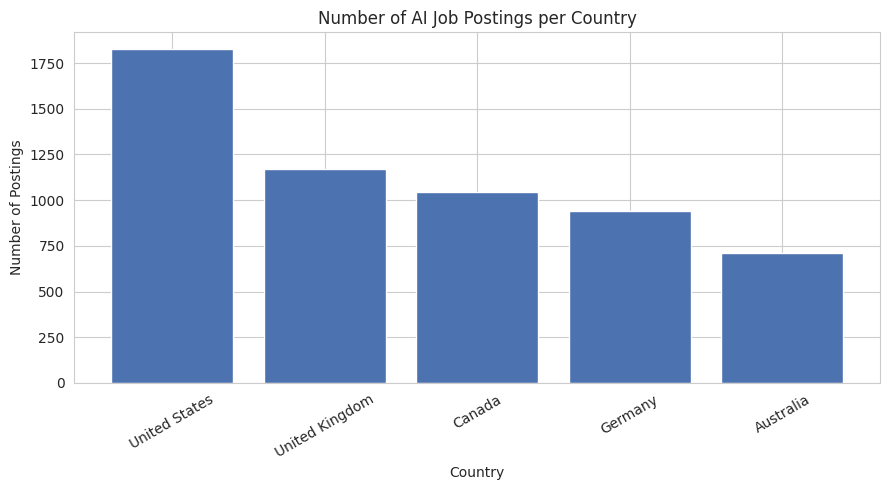

In [41]:
country_counts = df['country'].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(country_counts.index, country_counts.values, color='#4C72B0')
plt.title('Number of AI Job Postings per Country')
plt.xlabel('Country')
plt.ylabel('Number of Postings')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Explanation:** The United States dominates the dataset with the highest number of AI job postings, followed by the UK and Canada, reflecting where most of the scraped listings originate from.

**Chart 2 — Distribution of average salary (histogram)**

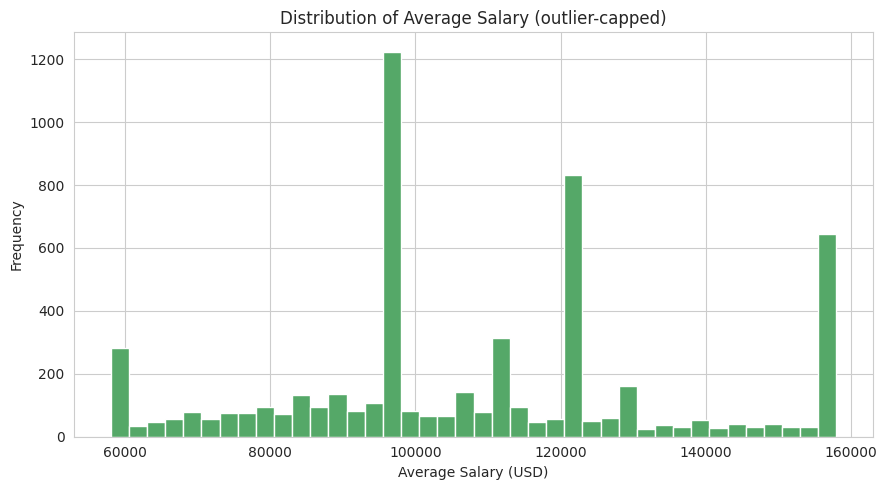

In [42]:
plt.figure(figsize=(9, 5))
plt.hist(df['salary_avg_capped'], bins=40, color='#55A868', edgecolor='white')
plt.title('Distribution of Average Salary (outlier-capped)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**Explanation:** The salary distribution is right-skewed but much more contained after capping outliers — most AI-related roles pay between roughly $70k and $150k, with a peak around $90k-$110k.

**Chart 3 — Job postings over time (line chart)**

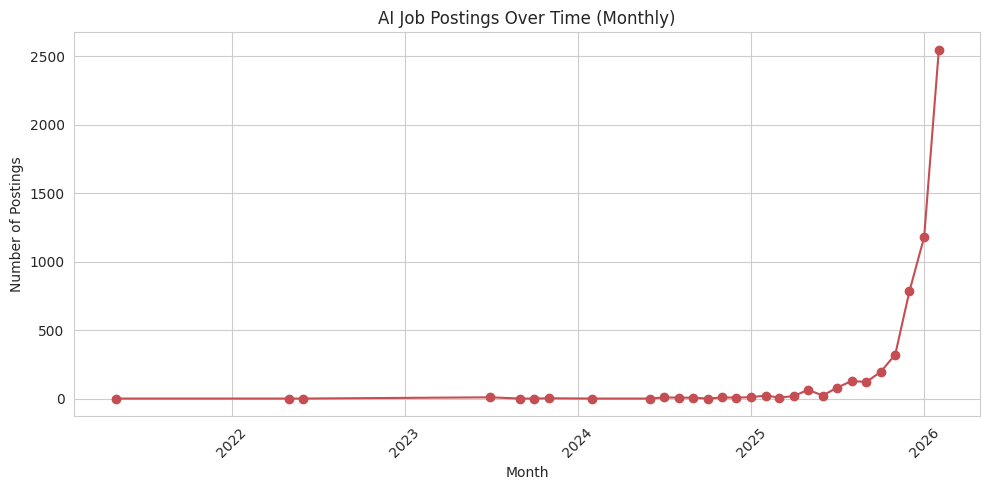

In [43]:
# Only rows with a real posted_date can be plotted over time (posted_date_disclosed == True)
dated = df[df['posted_date_disclosed']]
monthly = dated.groupby(dated['posted_date'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='#C44E52')
plt.title('AI Job Postings Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Explanation:** This line chart shows how the volume of scraped AI job postings changes month over month (using only the rows where `posted_date` is known), which can reveal seasonality or growth trends in AI hiring within the scraping window.

### 14.2 Seaborn

**Chart 4 — Salary by experience level (boxplot)**

/tmp/ipykernel_520/1511874223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary_avg_capped', order=order, palette='viridis')


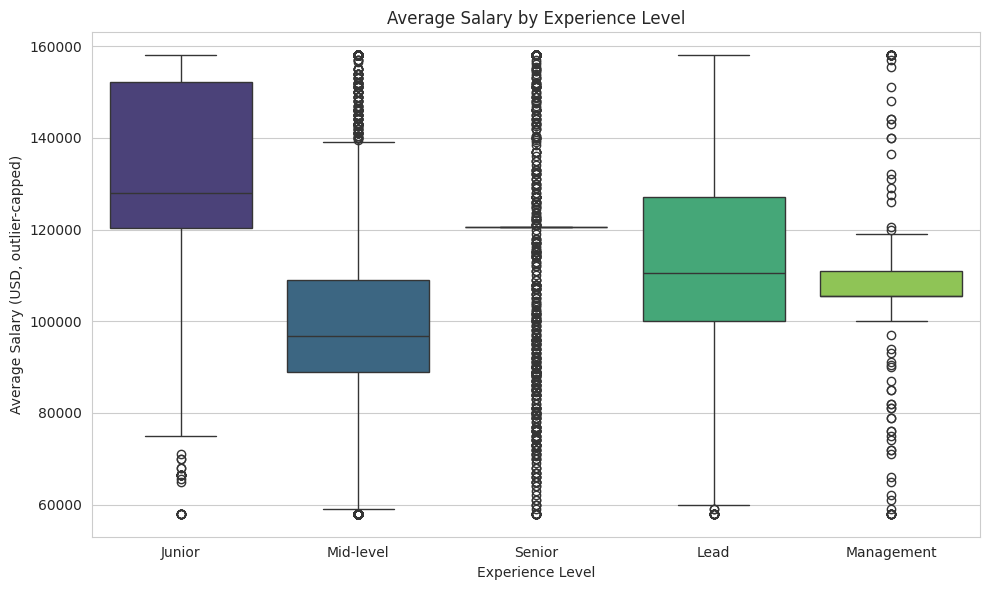

In [44]:
order = ['Junior', 'Mid-level', 'Senior', 'Lead', 'Management']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='experience_level', y='salary_avg_capped', order=order, palette='viridis')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD, outlier-capped)')
plt.tight_layout()
plt.show()


**Explanation:** Salary generally rises with seniority for `Mid-level` → `Senior` → `Lead`, but **`Junior` shows an unexpectedly high median**, close to `Senior` and above `Mid-level`, `Lead`, and `Management`. As documented in **Section 5.6**, this reflects a genuine label-quality issue in the source data (some 'Junior'-tagged postings have clearly senior job titles), not a real market pattern — so `experience_level` should be treated as a noisy signal rather than a perfectly clean seniority ladder.

**Chart 5 — Remote work type distribution (count plot)**

/tmp/ipykernel_520/3696883264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='remote_type', order=df['remote_type'].value_counts().index, palette='mako')


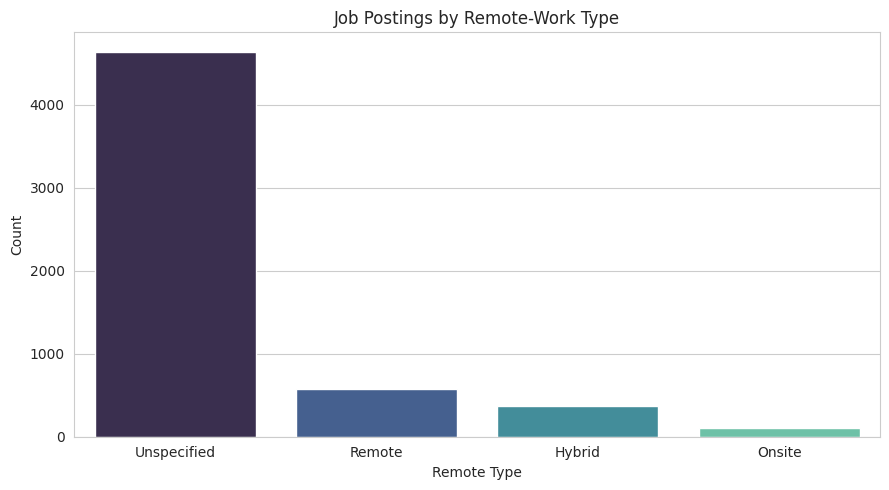

In [45]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='remote_type', order=df['remote_type'].value_counts().index, palette='mako')
plt.title('Job Postings by Remote-Work Type')
plt.xlabel('Remote Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Explanation:** Most postings don't specify a remote-work arrangement (`Unspecified`). Among those that do, fully **Remote** roles are the most common, followed by **Hybrid**, with very few strictly **Onsite** AI roles.

**Chart 6 — Correlation heatmap of numeric features**

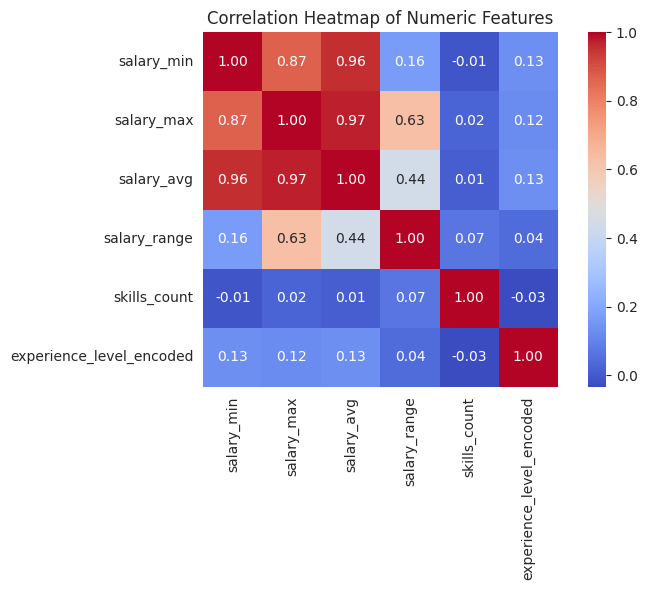

In [46]:
numeric_cols = ['salary_min', 'salary_max', 'salary_avg', 'salary_range', 'skills_count', 'experience_level_encoded']
corr = df_encoded[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


**Explanation:** `salary_min`, `salary_max`, and `salary_avg` are (unsurprisingly) very strongly correlated with each other. `experience_level_encoded` shows a positive correlation with salary, confirming that seniority is a meaningful salary driver. `skills_count` shows a weak correlation with salary, suggesting the number of listed skills alone isn't a strong salary predictor.

### 14.3 Plotly (Interactive)

**Chart 7 — Top 10 job titles (interactive bar chart)**

In [47]:
top_titles = df['job_title'].value_counts().head(10).reset_index()
top_titles.columns = ['job_title', 'count']

fig1 = px.bar(top_titles, x='count', y='job_title', orientation='h',
              title='Top 10 Most Common AI Job Titles',
              labels={'count': 'Number of Postings', 'job_title': 'Job Title'},
              color='count', color_continuous_scale='Blues')
fig1.update_layout(yaxis={'categoryorder': 'total ascending'})
display(HTML(fig1.to_html(include_plotlyjs='cdn', full_html=False)))


**Explanation:** 'Data Scientist' and 'AI Engineer' are by far the most frequently posted job titles in this dataset, followed by various Machine Learning Engineer variants.

**Chart 8 — Salary min vs. max by experience level (interactive scatter)**

In [48]:
fig2 = px.scatter(df, x='salary_min', y='salary_max', color='experience_level',
                   hover_data=['job_title', 'country'],
                   title='Salary Min vs. Salary Max by Experience Level',
                   labels={'salary_min': 'Minimum Salary (USD)', 'salary_max': 'Maximum Salary (USD)'},
                   opacity=0.6)
display(HTML(fig2.to_html(include_plotlyjs='cdn', full_html=False)))


**Explanation:** Most points fall along a diagonal band (min and max scale together), and higher experience levels (Senior, Lead, Management) cluster toward the upper-right, i.e. higher pay bands, while Junior roles cluster near the bottom-left.

**Chart 9 — Postings by country and experience level (interactive treemap)**

In [49]:
tree_data = df.groupby(['country', 'experience_level'], observed=True).size().reset_index(name='count')

fig3 = px.treemap(tree_data, path=['country', 'experience_level'], values='count',
                   title='AI Job Postings by Country and Experience Level',
                   color='count', color_continuous_scale='Teal')
display(HTML(fig3.to_html(include_plotlyjs='cdn', full_html=False)))


**Explanation:** The treemap breaks down postings hierarchically — country first, then experience level within each country — making it easy to see, for example, that Mid-level roles dominate within every country, and the US contributes the largest overall share of postings.

## 15. Final Validation

In [50]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5693 entries, 0 to 5692
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   job_title                   5693 non-null   str           
 1   company                     5693 non-null   str           
 2   city                        5693 non-null   str           
 3   salary_min                  5693 non-null   float64       
 4   salary_max                  5693 non-null   float64       
 5   experience_level            5693 non-null   category      
 6   required_skills             5693 non-null   str           
 7   posted_date                 5572 non-null   datetime64[us]
 8   source                      5693 non-null   str           
 9   job_description             5693 non-null   str           
 10  posted_date_disclosed       5693 non-null   bool          
 11  salary_disclosed            5693 non-null   bool          
 12  sal

In [51]:
df_encoded.describe()

,salary_min,salary_max,posted_date,salary_avg,salary_range,posted_year,posted_month,skills_count,salary_avg_capped,source_encoded,salary_min_standard,salary_max_standard,salary_avg_standard,salary_avg_capped_standard,salary_range_standard,skills_count_standard,salary_min_minmax,salary_max_minmax,salary_avg_minmax,salary_avg_capped_minmax,salary_range_minmax,skills_count_minmax
count,5693.000000,5693.000000,5572,5693.000000,5693.000000,5693.000000,5693.000000,5693.000000,5693.000000,5693.000000,5.693000e+03,5.693000e+03,5.693000e+03,5.693000e+03,5.693000e+03,5.693000e+03,5693.000000,5693.000000,5693.000000,5693.000000,5693.000000,5693.000000
mean,106922.887757,117957.316002,2025-12-26 11:35:42.426417,112440.101880,11034.428245,1982.579132,4.376954,0.256104,108335.938872,0.021254,4.992396e-17,1.996958e-17,-1.397871e-16,-9.235932e-17,2.995437e-17,9.984792e-18,0.219191,0.114230,0.155672,0.503359,0.020899,0.023282
min,21000.000000,30000.000000,2021-05-29 00:00:00,29000.000000,0.000000,-1.000000,-1.000000,0.000000,58000.000000,0.000000,-2.388463e+00,-1.922254e+00,-2.111108e+00,-1.868952e+00,-4.806364e-01,-3.847359e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,92000.000000,99000.000000,2025-12-05 00:00:00,95500.000000,0.000000,2025.000000,2.000000,0.000000,95500.000000,0.000000,-4.148227e-01,-4.143007e-01,-4.285995e-01,-4.765929e-01,-4.806364e-01,-3.847359e-01,0.181122,0.089610,0.124067,0.375000,0.000000,0.000000
50%,100000.000000,109000.000000,2026-01-29 00:00:00,105000.000000,6500.000000,2026.000000,2.000000,0.000000,105000.000000,0.000000,-1.924407e-01,-1.957567e-01,-1.882411e-01,-1.238620e-01,-1.975101e-01,-3.847359e-01,0.201531,0.102597,0.141791,0.470000,0.012311,0.000000
75%,114000.000000,127000.000000,2026-02-14 00:00:00,120500.000000,13000.000000,2026.000000,9.000000,0.000000,120500.000000,0.000000,1.967278e-01,1.976224e-01,2.039225e-01,4.516464e-01,8.561616e-02,-3.847359e-01,0.237245,0.125974,0.170709,0.625000,0.024621,0.000000
max,413000.000000,800000.000000,2026-02-22 00:00:00,565000.000000,528000.000000,2026.000000,12.000000,11.000000,158000.000000,1.000000,8.508254e+00,1.490563e+01,1.145016e+01,1.844005e+00,2.251793e+01,1.614017e+01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,35977.296874,45761.401560,NaN,39527.785622,22959.969105,292.331403,4.273278,0.665720,26935.075868,0.144243,1.000088e+00,1.000088e+00,1.000088e+00,1.000088e+00,1.000088e+00,1.000088e+00,0.091779,0.059430,0.073746,0.269351,0.043485,0.060520


In [52]:
print("Remaining missing values by column:")
print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])
print("\nRemaining duplicate rows:", df_encoded.duplicated().sum())
print("\nAll sources still present?", df_encoded['source'].unique())


Remaining missing values by column:
posted_date    121
dtype: int64

Remaining duplicate rows: 0

All sources still present? <StringArray>
['Adzuna', 'USAJobs']
Length: 2, dtype: str


In [53]:
df_encoded.head()

,job_title,company,city,salary_min,salary_max,experience_level,required_skills,posted_date,source,job_description,posted_date_disclosed,salary_disclosed,salary_avg,salary_range,posted_year,posted_month,posted_weekday,is_remote,skills_count,salary_avg_capped,experience_level_encoded,remote_Hybrid,remote_Onsite,remote_Remote,remote_Unspecified,country_Australia,country_Canada,country_Germany,country_United Kingdom,country_United States,source_encoded,salary_min_standard,salary_max_standard,salary_avg_standard,salary_avg_capped_standard,salary_range_standard,skills_count_standard,salary_min_minmax,salary_max_minmax,salary_avg_minmax,salary_avg_capped_minmax,salary_range_minmax,skills_count_minmax
0,AI Engineer,Jobot,Mount Carmel,160000.0,160000.0,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...,True,True,160000.0,0.0,2026,2,Monday,False,1,158000.0,3,False,False,False,True,False,False,False,False,True,0,1.475424,0.918818,1.203307,1.844005,-0.480636,1.117528,0.354592,0.168831,0.244403,1.00,0.0,0.090909
1,AI Engineer,Jobot,The Gap,175000.0,175000.0,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...,True,True,175000.0,0.0,2026,2,Monday,False,1,158000.0,3,False,False,False,True,False,False,False,False,True,0,1.892390,1.246633,1.582821,1.844005,-0.480636,1.117528,0.392857,0.188312,0.272388,1.00,0.0,0.090909
2,AI Engineer,Jobot,Nashville,218000.0,218000.0,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...,True,True,218000.0,0.0,2026,2,Monday,False,1,158000.0,3,False,False,False,True,False,False,False,False,True,0,3.087694,2.186373,2.670759,1.844005,-0.480636,1.117528,0.502551,0.244156,0.352612,1.00,0.0,0.090909
3,Frontend/AI Engineer,Jobot,New York City,112000.0,112000.0,Mid-level,Not specified,2026-02-16,Adzuna,Manufacturing Company looking for Business Sys...,True,True,112000.0,0.0,2026,2,Monday,False,0,112000.0,1,False,False,False,True,False,False,False,False,True,0,0.141132,-0.130194,-0.011135,0.136045,-0.480636,-0.384736,0.232143,0.106494,0.154851,0.54,0.0,0.000000
4,AI Engineering Lead,Jobot,Irvine,92000.0,92000.0,Senior,Not specified,2026-02-16,Adzuna,Lead Financial Insights and Reporting as a Sen...,True,True,92000.0,0.0,2026,2,Monday,False,0,92000.0,2,False,False,False,True,False,False,False,False,True,0,-0.414823,-0.567281,-0.517153,-0.606546,-0.480636,-0.384736,0.181122,0.080519,0.117537,0.34,0.0,0.000000


**Explanation:** No duplicate rows remain. The **only** remaining missing values are in the raw `posted_date` column itself (123 rows, ~2%) — and that's intentional, not a bug: those rows are flagged via `posted_date_disclosed` and their derived features are safely placeholder-filled, so **no rows or data sources were silently dropped** (both `Adzuna` and `USAJobs` are confirmed present above, fixing the earlier issue where `USAJobs` was accidentally deleted entirely). The dataset contains the original cleaned columns plus all engineered features (`salary_avg`, `salary_range`, `is_remote`, `skills_count`, date parts), cleaned `city`/`company` text, the outlier-capped salary, ordinal/one-hot/label encodings, and both standard- and min-max-scaled numeric features — ready for further analysis or machine learning.

## 16. Save Clean Dataset

In [54]:
df_encoded.to_csv('ai_jobs_global_processed.csv', index=False)
print(f"Saved processed dataset: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")


Saved processed dataset: 5693 rows, 43 columns


**Summary of the full preprocessing pipeline:**
1. Explored raw data (shape, types, missing values, duplicates, invalid values).
2. Fixed data types (`posted_date` → datetime, low-cardinality text → category).
3. Handled missing values per-column with justified strategies (fill, flag+impute, or flag+keep — **never** a blind drop that could silently delete an entire data source).
4. Removed invalid rows: impossible (`min > max`), exactly-zero, **and domain-implausible (<$10,000/year) salaries**; confirmed no duplicate rows.
5. Cleaned text fields: stripped whitespace, **fixed country-name/neighborhood noise in `city`**, **merged case-variant duplicate `company` names and removed scraping garbage**, and dropped the constant `currency` column.
6. Engineered new features (`salary_avg`, `salary_range`, date parts, `is_remote`, `skills_count`), handling the legitimately-missing dates with clear placeholders instead of dropping rows.
7. Detected and capped salary outliers using the IQR method.
8. Encoded categorical variables (ordinal, one-hot, label).
9. Scaled numeric features with both StandardScaler and MinMaxScaler.
10. Visualized the data with 3 Matplotlib, 3 Seaborn, and 3 Plotly charts.
11. Exported the final processed dataset to `ai_jobs_global_processed.csv`.

**Fixes applied in this revision:** (1) recovered the 123 `USAJobs` rows that were previously deleted entirely due to a blanket `dropna` on `posted_date`; (2) added a domain-knowledge check that removes implausibly low (but non-zero) salaries the IQR method alone wouldn't catch as cleanly; (3) cleaned country-name/neighborhood noise out of `city`; (4) merged case-variant duplicate `company` names and removed scraping garbage like `'at'`.